# Multi-Experiment Scaling Evaluation

This notebook aggregates results across experiment folders and plots performance metrics as workflow size increases.

Set `EXPERIMENT_DIR_NAMES` in the setup cell to use an explicit list of experiment folders, or leave it empty to auto-discover `experiments/exp_wf*`.

In [29]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional but useful for cleaner tables in notebook.
from IPython.display import display

ROOT = Path.cwd()
EXPERIMENTS_DIR = ROOT / "experiments"

print(f"Workspace root: {ROOT}")
print(f"Experiments dir: {EXPERIMENTS_DIR}")

Workspace root: /Users/gtzanettis/Documents/Projects/agent-task-distribution
Experiments dir: /Users/gtzanettis/Documents/Projects/agent-task-distribution/experiments


In [30]:
from typing import Optional


def discover_experiment_dirs(experiments_dir: Path) -> list[Path]:
    dirs = [p for p in experiments_dir.glob("exp_wf*") if p.is_dir()]
    return sorted(dirs)


def resolve_experiment_dirs(experiments_dir: Path, experiment_dir_names: Optional[list[str]] = None) -> list[Path]:
    if experiment_dir_names is not None and len(experiment_dir_names) > 0:
        return [experiments_dir / name for name in experiment_dir_names]
    return discover_experiment_dirs(experiments_dir)


def infer_workflow_size(exp_dir: Path) -> Optional[int]:
    # Primary source: count workflow KPI columns in selected step KPI CSV.
    selected_csv = exp_dir / "evaluation_selected_step_kpis.csv"
    if selected_csv.exists():
        df_head = pd.read_csv(selected_csv, nrows=1)
        wf_cols = [c for c in df_head.columns if re.fullmatch(r"wf\d+_violation_rate", c)]
        if wf_cols:
            return len(wf_cols)

    # Fallback: extract wfNN from folder name like exp_wf02 or exp_wf10_workers6.
    match = re.search(r"wf(\d+)", exp_dir.name)
    if match:
        return int(match.group(1))

    return None


def read_summary(path: Path) -> Optional[dict]:
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def collect_scenario_rows(exp_dir: Path, workflow_size: Optional[int]) -> list[dict]:
    rows: list[dict] = []
    for summary_path in sorted(exp_dir.glob("evaluation_*_summary.json")):
        summary = read_summary(summary_path)
        if not summary:
            continue

        row = {
            "experiment": exp_dir.name,
            "workflow_size": workflow_size,
            "scenario": summary.get("scenario"),
            "n_agents": len(summary.get("agents", [])),
            "total_violations_across_steps": summary.get("total_violations_across_steps"),
            "mean_step_total_violations": summary.get("mean_step_total_violations"),
            "training_mean_episode_total_violations": summary.get("training_mean_episode_total_violations"),
        }

        # Aggregate node-level CPU means into a single comparable metric.
        cpu_means = [
            v for k, v in summary.items()
            if k.endswith("_avg_cpu_usage_pct_mean") and isinstance(v, (int, float))
        ]
        row["cluster_avg_cpu_usage_pct_mean"] = float(np.mean(cpu_means)) if cpu_means else np.nan
        row["cluster_max_cpu_usage_pct_mean"] = float(np.max(cpu_means)) if cpu_means else np.nan

        rows.append(row)

    return rows


# Set this to a list of folder names, for example ["exp_wf01", "exp_wf02"].
# Leave it as None or an empty list to auto-discover experiments/exp_wf*.
EXPERIMENT_DIR_NAMES = ["exp_wf01", "exp_wf02", "exp_wf03", "exp_wf04", "exp_wf05", "exp_wf06", "exp_wf07", "exp_wf08", "exp_wf09", "exp_wf10"]

experiment_dirs = resolve_experiment_dirs(EXPERIMENTS_DIR, EXPERIMENT_DIR_NAMES)
if not experiment_dirs:
    raise FileNotFoundError(f"No experiment folders found under {EXPERIMENTS_DIR}")

all_rows: list[dict] = []
for exp_dir in experiment_dirs:
    wf_size = infer_workflow_size(exp_dir)
    all_rows.extend(collect_scenario_rows(exp_dir, wf_size))

metrics_df = pd.DataFrame(all_rows)
if metrics_df.empty:
    raise RuntimeError("No evaluation summary files were found in experiment folders.")

metrics_df = metrics_df.sort_values(["workflow_size", "scenario", "experiment"], na_position="last").reset_index(drop=True)

print(f"Discovered {len(experiment_dirs)} experiment folders")
print(f"Collected {len(metrics_df)} scenario summaries")
display(metrics_df.head(20))

Discovered 10 experiment folders
Collected 50 scenario summaries


,experiment,workflow_size,scenario,n_agents,total_violations_across_steps,mean_step_total_violations,training_mean_episode_total_violations,cluster_avg_cpu_usage_pct_mean,cluster_max_cpu_usage_pct_mean
0,exp_wf01,1,one_agent_all_tasks,1,31,1.722222,34.81,34.002525,54.886364
1,exp_wf01,1,one_agent_per_node,3,25,1.315789,29.14,32.651515,53.313397
2,exp_wf01,1,one_agent_per_task,3,25,1.315789,29.14,32.651515,53.313397
3,exp_wf01,1,one_agent_per_workflow,1,31,1.722222,34.81,34.002525,54.886364
4,exp_wf01,1,selected,1,31,1.722222,34.81,34.002525,54.886364
5,exp_wf02,2,one_agent_all_tasks,1,7,0.777778,30.80,55.513468,80.505051
6,exp_wf02,2,one_agent_per_node,3,58,6.444444,38.79,55.185185,84.570707
7,exp_wf02,2,one_agent_per_task,6,51,5.666667,40.82,54.612795,84.823232
8,exp_wf02,2,one_agent_per_workflow,2,48,5.333333,36.19,55.782828,87.676768
9,exp_wf02,2,selected,4,22,2.444444,32.19,59.570707,88.232323


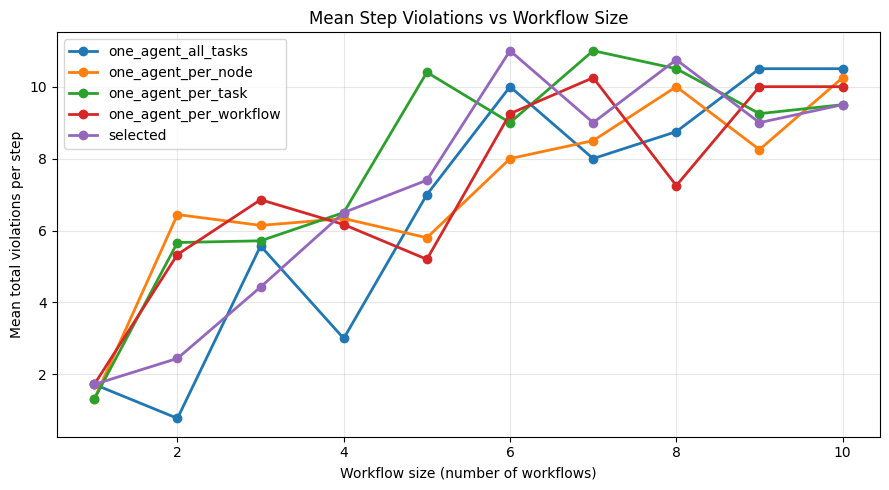

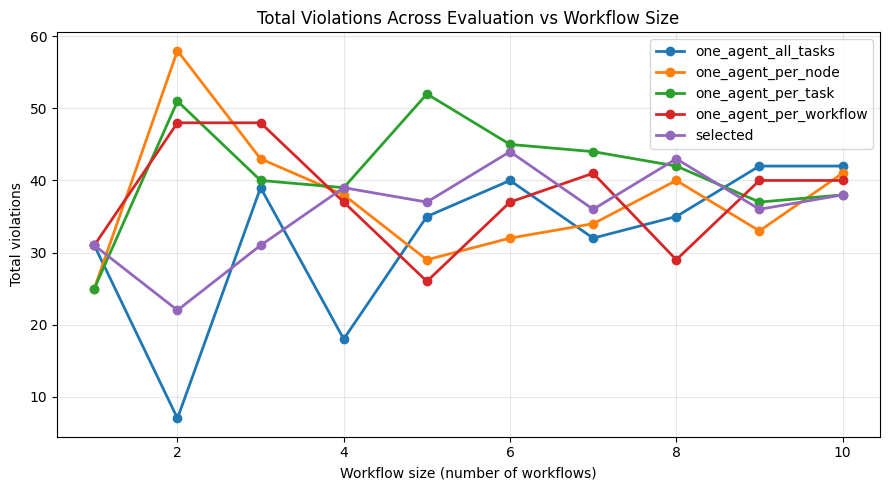

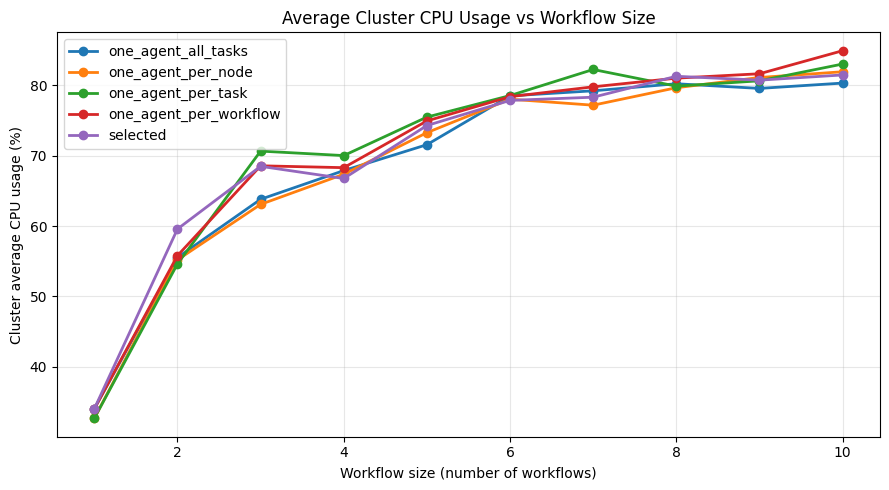

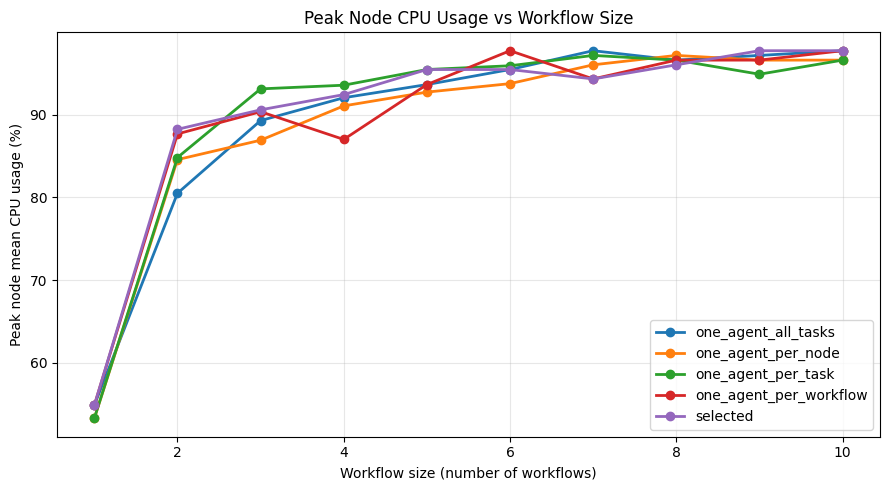

In [31]:
# Optional scenario filter.
# Set to None to include all scenarios, or set to a list such as ["selected", "one_agent_per_task"].
SCENARIOS_TO_PLOT = None

if SCENARIOS_TO_PLOT is None:
    plot_df = metrics_df.copy()
else:
    plot_df = metrics_df[metrics_df["scenario"].isin(SCENARIOS_TO_PLOT)].copy()

if plot_df.empty:
    raise RuntimeError("No rows left after scenario filtering.")


def lineplot_by_workflow_size(df: pd.DataFrame, y_col: str, title: str, ylabel: str):
    fig, ax = plt.subplots(figsize=(9, 5))

    for scenario in sorted(df["scenario"].dropna().unique()):
        part = df[df["scenario"] == scenario].sort_values("workflow_size")
        ax.plot(
            part["workflow_size"],
            part[y_col],
            marker="o",
            linewidth=2,
            label=scenario,
        )

    ax.set_title(title)
    ax.set_xlabel("Workflow size (number of workflows)")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    return fig, ax


lineplot_by_workflow_size(
    plot_df,
    y_col="mean_step_total_violations",
    title="Mean Step Violations vs Workflow Size",
    ylabel="Mean total violations per step",
)

lineplot_by_workflow_size(
    plot_df,
    y_col="total_violations_across_steps",
    title="Total Violations Across Evaluation vs Workflow Size",
    ylabel="Total violations",
)

lineplot_by_workflow_size(
    plot_df,
    y_col="cluster_avg_cpu_usage_pct_mean",
    title="Average Cluster CPU Usage vs Workflow Size",
    ylabel="Cluster average CPU usage (%)",
)

lineplot_by_workflow_size(
    plot_df,
    y_col="cluster_max_cpu_usage_pct_mean",
    title="Peak Node CPU Usage vs Workflow Size",
    ylabel="Peak node mean CPU usage (%)",
)

plt.show()

In [32]:
summary_table = (
    plot_df[
        [
            "experiment",
            "workflow_size",
            "scenario",
            "n_agents",
            "mean_step_total_violations",
            "total_violations_across_steps",
            "cluster_avg_cpu_usage_pct_mean",
            "cluster_max_cpu_usage_pct_mean",
        ]
    ]
    .sort_values(["workflow_size", "scenario", "experiment"])
    .reset_index(drop=True)
)

print("Scaling summary table:")
display(summary_table)

print("Per-scenario trend (mean across experiments with same workflow size):")
trend_table = (
    plot_df.groupby(["scenario", "workflow_size"], as_index=False)[
        [
            "mean_step_total_violations",
            "total_violations_across_steps",
            "cluster_avg_cpu_usage_pct_mean",
            "cluster_max_cpu_usage_pct_mean",
        ]
    ]
    .mean(numeric_only=True)
    .sort_values(["scenario", "workflow_size"])
)
display(trend_table)

Scaling summary table:


,experiment,workflow_size,scenario,n_agents,mean_step_total_violations,total_violations_across_steps,cluster_avg_cpu_usage_pct_mean,cluster_max_cpu_usage_pct_mean
0,exp_wf01,1,one_agent_all_tasks,1,1.722222,31,34.002525,54.886364
1,exp_wf01,1,one_agent_per_node,3,1.315789,25,32.651515,53.313397
2,exp_wf01,1,one_agent_per_task,3,1.315789,25,32.651515,53.313397
3,exp_wf01,1,one_agent_per_workflow,1,1.722222,31,34.002525,54.886364
4,exp_wf01,1,selected,1,1.722222,31,34.002525,54.886364
5,exp_wf02,2,one_agent_all_tasks,1,0.777778,7,55.513468,80.505051
6,exp_wf02,2,one_agent_per_node,3,6.444444,58,55.185185,84.570707
7,exp_wf02,2,one_agent_per_task,6,5.666667,51,54.612795,84.823232
8,exp_wf02,2,one_agent_per_workflow,2,5.333333,48,55.782828,87.676768
9,exp_wf02,2,selected,4,2.444444,22,59.570707,88.232323


Per-scenario trend (mean across experiments with same workflow size):


,scenario,workflow_size,mean_step_total_violations,total_violations_across_steps,cluster_avg_cpu_usage_pct_mean,cluster_max_cpu_usage_pct_mean
0,one_agent_all_tasks,1,1.722222,31.0,34.002525,54.886364
1,one_agent_all_tasks,2,0.777778,7.0,55.513468,80.505051
2,one_agent_all_tasks,3,5.571429,39.0,63.798701,89.285714
3,one_agent_all_tasks,4,3.000000,18.0,67.878788,92.045455
4,one_agent_all_tasks,5,7.000000,35.0,71.560606,93.636364
5,one_agent_all_tasks,6,10.000000,40.0,78.503788,95.454545
6,one_agent_all_tasks,7,8.000000,32.0,79.223485,97.727273
7,one_agent_all_tasks,8,8.750000,35.0,80.227273,96.590909
8,one_agent_all_tasks,9,10.500000,42.0,79.564394,97.159091
9,one_agent_all_tasks,10,10.500000,42.0,80.321970,97.727273
